TimesNewRoman.ttf not found. Using DejaVu Serif.


,Sample,Cr_mg_per_kg_Fe,Ni_mg_per_kg_Fe,Mn_mg_per_kg_Fe,Fe_g_per_L,Fe_g_per_L_note,Sample_type
0,TN,141,196,3151,187.0,187,Recovered product
1,SKF GBG,35,221,2590,229.0,229,Recovered product
2,SKF Bio,18,105,2986,210.0,210,Recovered product
3,SKF A1,28,76,3479,211.0,211,Recovered product
4,SKF A2 leachate,2247,139,3571,NaN,>187,Process leachate
5,Commercial FeCl3,40,69,2087,NaN,N.D.,Commercial reference


,Sample,Sample_type,Cr_mg_per_kg_Fe,Cr_class,Ni_mg_per_kg_Fe,Ni_class,Mn_mg_per_kg_Fe,Mn_class,Fe_g_per_L_note,Final_quality
0,TN,Recovered product,141,Type 2,196,Type 2,3151,Type 1,187,Type 2
1,SKF GBG,Recovered product,35,Type 1,221,Type 2,2590,Type 1,229,Type 2
2,SKF Bio,Recovered product,18,Type 1,105,Type 2,2986,Type 1,210,Type 2
3,SKF A1,Recovered product,28,Type 1,76,Type 2,3479,Type 1,211,Type 2
4,SKF A2 leachate,Process leachate,2247,Fail,139,Type 2,3571,Type 1,>187,Fail
5,Commercial FeCl3,Commercial reference,40,Type 1,69,Type 2,2087,Type 1,N.D.,Type 2


,Sample,Cr_mg_per_kg_Fe,Ni_mg_per_kg_Fe,Mn_mg_per_kg_Fe,Fe_g_per_L_note,Quality_score,Rank
0,SKF Bio,18,105,2986,210,59.87,1
1,SKF A1,28,76,3479,211,50.89,2
2,SKF GBG,35,221,2590,229,36.61,3
3,TN,141,196,3151,187,22.44,4


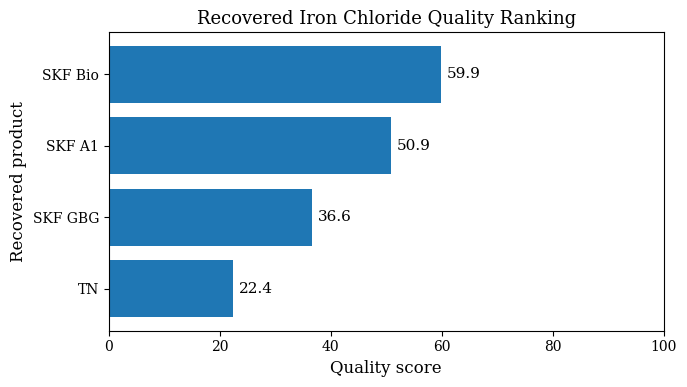

,Cr,Ni,Mn
Sample,,,
TN,141,196,3151
SKF GBG,35,221,2590
SKF Bio,18,105,2986
SKF A1,28,76,3479
Commercial FeCl3,40,69,2087


,Cr,Ni,Mn
Sample,,,
TN,1.973,0.994,0.609
SKF GBG,-0.387,1.391,-0.559
SKF Bio,-0.766,-0.451,0.265
SKF A1,-0.543,-0.911,1.291
Commercial FeCl3,-0.276,-1.022,-1.606


Maximum Ward linkage distance: 3.623


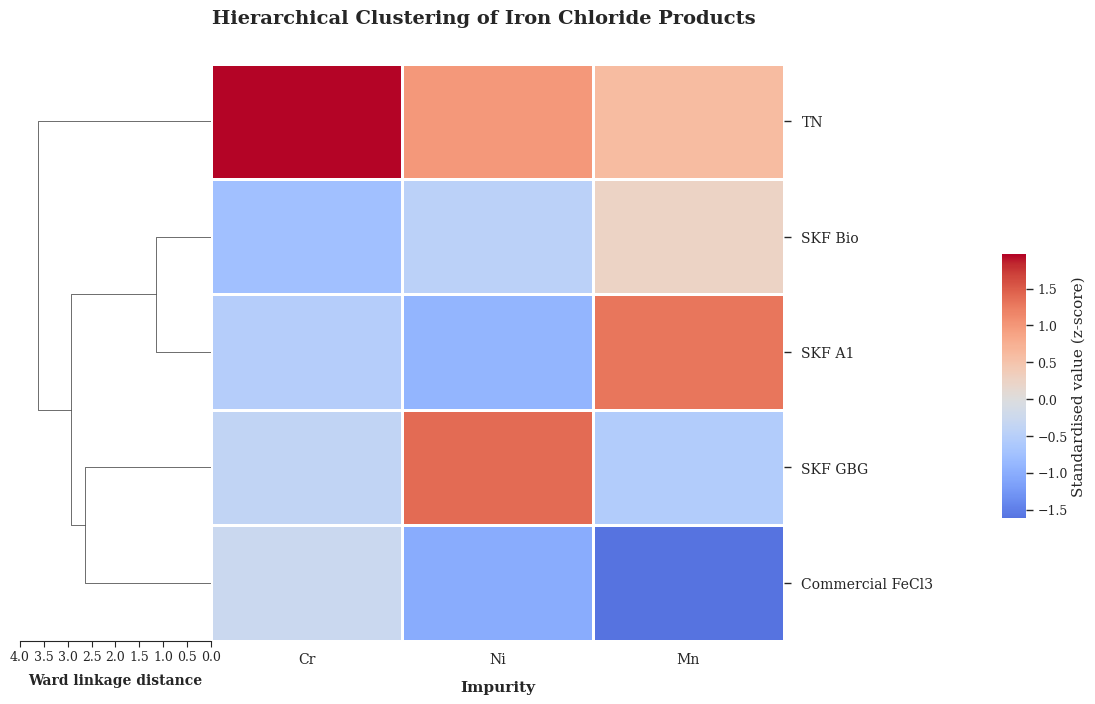

In [1]:
# ============================================================
# AI-Assisted Hydrometallurgy Analysis
# Iron Chloride Product Quality Assessment
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage


# ============================================================
# 1. Figure font configuration
# ============================================================
# To reproduce figures using Times New Roman in Google Colab,
# upload a legally obtained TimesNewRoman.ttf file to:
# /content/TimesNewRoman.ttf
#
# If the file is unavailable, the code falls back to
# DejaVu Serif so that the notebook remains fully executable.

font_path = "/content/TimesNewRoman.ttf"

if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    print(f"Font loaded: {font_name}")
else:
    font_name = "DejaVu Serif"
    print("TimesNewRoman.ttf not found. Using DejaVu Serif.")

mpl.rcParams["font.family"] = font_name
mpl.rcParams["font.size"] = 11
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["axes.titlesize"] = 13
mpl.rcParams["xtick.labelsize"] = 10
mpl.rcParams["ytick.labelsize"] = 10
mpl.rcParams["savefig.dpi"] = 600


# ============================================================
# 2. Experimental dataset
# ============================================================

product_quality_data = {
    "Sample": [
        "TN",
        "SKF GBG",
        "SKF Bio",
        "SKF A1",
        "SKF A2 leachate",
        "Commercial FeCl3"
    ],

    "Cr_mg_per_kg_Fe": [
        141,
        35,
        18,
        28,
        2247,
        40
    ],

    "Ni_mg_per_kg_Fe": [
        196,
        221,
        105,
        76,
        139,
        69
    ],

    "Mn_mg_per_kg_Fe": [
        3151,
        2590,
        2986,
        3479,
        3571,
        2087
    ],

    "Fe_g_per_L": [
        187,
        229,
        210,
        211,
        np.nan,   # Reported as >187 g/L
        np.nan    # Not determined
    ],

    "Fe_g_per_L_note": [
        "187",
        "229",
        "210",
        "211",
        ">187",
        "N.D."
    ],

    "Sample_type": [
        "Recovered product",
        "Recovered product",
        "Recovered product",
        "Recovered product",
        "Process leachate",
        "Commercial reference"
    ]
}

df_quality = pd.DataFrame(product_quality_data)

display(df_quality)


# ============================================================
# 3. EN 888:2023 impurity limits
# ============================================================

limits = {
    "Cr": {
        "Type 1": 50,
        "Type 2": 350,
        "Type 3": 500
    },

    "Ni": {
        "Type 1": 60,
        "Type 2": 350,
        "Type 3": 500
    },

    "Mn": {
        "Type 1": 5000,
        "Type 2": 10000,
        "Type 3": 20000
    }
}


# ============================================================
# 4. Quality classification
# ============================================================

def classify_quality(value, element):
    """Classify an impurity concentration according to the
    specified EN 888:2023 limits."""

    if pd.isna(value):
        return "N.D."

    if value <= limits[element]["Type 1"]:
        return "Type 1"
    elif value <= limits[element]["Type 2"]:
        return "Type 2"
    elif value <= limits[element]["Type 3"]:
        return "Type 3"
    else:
        return "Fail"


df_quality["Cr_class"] = df_quality["Cr_mg_per_kg_Fe"].apply(
    lambda x: classify_quality(x, "Cr")
)

df_quality["Ni_class"] = df_quality["Ni_mg_per_kg_Fe"].apply(
    lambda x: classify_quality(x, "Ni")
)

df_quality["Mn_class"] = df_quality["Mn_mg_per_kg_Fe"].apply(
    lambda x: classify_quality(x, "Mn")
)


# ============================================================
# 5. Final quality classification
# ============================================================

class_severity = {
    "Type 1": 1,
    "Type 2": 2,
    "Type 3": 3,
    "Fail": 4,
    "N.D.": np.nan
}


def get_final_quality(row):
    """Assign the final quality class using the most restrictive
    impurity classification."""

    classes = [
        row["Cr_class"],
        row["Ni_class"],
        row["Mn_class"]
    ]

    valid_classes = [
        c for c in classes
        if c != "N.D."
    ]

    if len(valid_classes) == 0:
        return "N.D."

    return max(
        valid_classes,
        key=lambda x: class_severity[x]
    )


df_quality["Final_quality"] = df_quality.apply(
    get_final_quality,
    axis=1
)


classification_table = df_quality[
    [
        "Sample",
        "Sample_type",
        "Cr_mg_per_kg_Fe",
        "Cr_class",
        "Ni_mg_per_kg_Fe",
        "Ni_class",
        "Mn_mg_per_kg_Fe",
        "Mn_class",
        "Fe_g_per_L_note",
        "Final_quality"
    ]
]

display(classification_table)


# ============================================================
# 6. Impurity-based quality score
# ============================================================
# Lower impurity concentration = higher score
#
# Target limits:
# Cr = 50 mg/kg Fe
# Ni = 350 mg/kg Fe
# Mn = 5000 mg/kg Fe
#
# Weighting:
# Cr = 45%
# Ni = 30%
# Mn = 25%
# ============================================================

target_limits = {
    "Cr_mg_per_kg_Fe": 50,
    "Ni_mg_per_kg_Fe": 350,
    "Mn_mg_per_kg_Fe": 5000
}


def impurity_score(value, target):
    """Calculate a normalized impurity score between 0 and 1."""

    score = 1 - (value / target)

    return max(
        0,
        min(1, score)
    )


df_quality["Cr_score"] = df_quality["Cr_mg_per_kg_Fe"].apply(
    lambda x: impurity_score(
        x,
        target_limits["Cr_mg_per_kg_Fe"]
    )
)

df_quality["Ni_score"] = df_quality["Ni_mg_per_kg_Fe"].apply(
    lambda x: impurity_score(
        x,
        target_limits["Ni_mg_per_kg_Fe"]
    )
)

df_quality["Mn_score"] = df_quality["Mn_mg_per_kg_Fe"].apply(
    lambda x: impurity_score(
        x,
        target_limits["Mn_mg_per_kg_Fe"]
    )
)


df_quality["Quality_score"] = 100 * (
    0.45 * df_quality["Cr_score"] +
    0.30 * df_quality["Ni_score"] +
    0.25 * df_quality["Mn_score"]
)


# ============================================================
# 7. Ranking of recovered products
# ============================================================
# The process leachate and commercial reference are excluded
# from the recovered-product ranking.
# ============================================================

recovered_products = df_quality[
    df_quality["Sample_type"] == "Recovered product"
].copy()


quality_ranking = recovered_products[
    [
        "Sample",
        "Cr_mg_per_kg_Fe",
        "Ni_mg_per_kg_Fe",
        "Mn_mg_per_kg_Fe",
        "Fe_g_per_L_note",
        "Quality_score"
    ]
].sort_values(
    by="Quality_score",
    ascending=False
).reset_index(drop=True)


quality_ranking["Rank"] = np.arange(
    1,
    len(quality_ranking) + 1
)

display(quality_ranking.round({"Quality_score": 2}))


# ============================================================
# 8. Quality-ranking bar chart
# ============================================================

ranking_plot = quality_ranking.sort_values(
    by="Quality_score",
    ascending=True
)

plt.figure(figsize=(7, 4))

plt.barh(
    ranking_plot["Sample"],
    ranking_plot["Quality_score"]
)

plt.xlabel("Quality score")
plt.ylabel("Recovered product")
plt.title("Recovered Iron Chloride Quality Ranking")

plt.xlim(0, 100)

for index, value in enumerate(
    ranking_plot["Quality_score"]
):
    plt.text(
        value + 1,
        index,
        f"{value:.1f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "Recovered_Product_Quality_Ranking.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 9. Dataset for hierarchical clustering
# ============================================================
# SKF A2 leachate is excluded because it represents an
# intermediate process stream rather than a final product.
#
# Clustering is based on Cr, Ni, and Mn concentrations.
# ============================================================

cluster_data = df_quality.loc[
    df_quality["Sample"] != "SKF A2 leachate",
    [
        "Sample",
        "Cr_mg_per_kg_Fe",
        "Ni_mg_per_kg_Fe",
        "Mn_mg_per_kg_Fe"
    ]
].copy()


cluster_data = cluster_data.rename(
    columns={
        "Cr_mg_per_kg_Fe": "Cr",
        "Ni_mg_per_kg_Fe": "Ni",
        "Mn_mg_per_kg_Fe": "Mn"
    }
).set_index("Sample")


display(cluster_data)


# ============================================================
# 10. Standardisation using z-scores
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    cluster_data
)

scaled_df = pd.DataFrame(
    X_scaled,
    index=cluster_data.index,
    columns=cluster_data.columns
)

display(scaled_df.round(3))


# ============================================================
# 11. Ward hierarchical clustering
# ============================================================
# Ward linkage is applied to the standardized impurity data.
# ============================================================

Z = linkage(
    X_scaled,
    method="ward"
)

max_distance = Z[:, 2].max()

print(
    "Maximum Ward linkage distance:",
    round(max_distance, 3)
)


# ============================================================
# 12. Hierarchical clustermap
# ============================================================

sns.set_theme(
    context="paper",
    style="white",
    font=font_name,
    font_scale=1.15
)


g = sns.clustermap(
    scaled_df,

    row_linkage=Z,
    col_cluster=False,

    cmap="coolwarm",
    center=0,

    linewidths=0.8,
    linecolor="white",

    figsize=(9.6, 6.6),

    dendrogram_ratio=(0.25, 0.04),

    cbar_pos=(1.04, 0.25, 0.025, 0.40),

    cbar_kws={
        "label": "Standardised value (z-score)"
    }
)


# ============================================================
# 13. Heatmap formatting
# ============================================================

g.ax_heatmap.set_xlabel(
    "Impurity",
    fontname=font_name,
    fontweight="bold",
    labelpad=10
)

g.ax_heatmap.set_ylabel("")

g.ax_heatmap.yaxis.tick_right()

g.ax_heatmap.tick_params(
    axis="y",
    labelright=True,
    labelleft=False,
    pad=8
)

g.ax_heatmap.set_xticklabels(
    ["Cr", "Ni", "Mn"],
    rotation=0,
    fontname=font_name
)

g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    rotation=0,
    fontname=font_name
)


# ============================================================
# 14. Ward linkage distance axis
# ============================================================

ax_den = g.ax_row_dendrogram

ax_den.set_axis_on()

# Maximum linkage distance appears on the left;
# zero is adjacent to the heatmap.
ax_den.set_xlim(
    max_distance * 1.08,
    0
)

tick_step = 0.5

ward_ticks = np.arange(
    0,
    np.ceil(max_distance / tick_step)
    * tick_step + tick_step,
    tick_step
)

ax_den.set_xticks(
    ward_ticks
)

ax_den.set_xticklabels(
    [f"{value:.1f}" for value in ward_ticks],
    fontsize=9,
    fontname=font_name
)

ax_den.tick_params(
    axis="x",
    which="both",
    bottom=True,
    labelbottom=True,
    top=False,
    labeltop=False,
    length=4,
    width=0.8,
    pad=3
)

ax_den.set_yticks([])

ax_den.tick_params(
    axis="y",
    left=False,
    right=False,
    labelleft=False,
    labelright=False
)

ax_den.set_xlabel(
    "Ward linkage distance",
    fontsize=10,
    fontname=font_name,
    fontweight="bold",
    labelpad=7
)

ax_den.spines["bottom"].set_visible(True)
ax_den.spines["bottom"].set_linewidth(0.8)

ax_den.spines["top"].set_visible(False)
ax_den.spines["left"].set_visible(False)
ax_den.spines["right"].set_visible(False)


# ============================================================
# 15. Colorbar formatting
# ============================================================

g.cax.set_ylabel(
    "Standardised value (z-score)",
    fontname=font_name,
    fontsize=11,
    rotation=90,
    labelpad=3
)

for label in g.cax.get_yticklabels():
    label.set_fontname(font_name)
    label.set_fontsize(9)


# ============================================================
# 16. Figure title
# ============================================================

g.fig.suptitle(
    "Hierarchical Clustering of Iron Chloride Products",
    fontname=font_name,
    fontsize=14,
    fontweight="bold",
    y=1.02
)


# Apply selected font explicitly
for ax in [
    g.ax_heatmap,
    g.ax_row_dendrogram,
    g.cax
]:
    for label in ax.get_xticklabels():
        label.set_fontname(font_name)

    for label in ax.get_yticklabels():
        label.set_fontname(font_name)


# ============================================================
# 17. Save clustering figure
# ============================================================

g.fig.savefig(
    "Hierarchical_Clustermap_Ward_Axis.png",
    dpi=600,
    bbox_inches="tight"
)

g.fig.savefig(
    "Hierarchical_Clustermap_Ward_Axis.jpg",
    dpi=600,
    bbox_inches="tight"
)

g.fig.savefig(
    "Hierarchical_Clustermap_Ward_Axis.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()